In [3]:
import os
import sqlite3
import pandas as pd

# Find database paths natively
current_dir = os.getcwd()
db_path = os.path.join(current_dir, "mlflow.db")
print(f"🔄 Fetching direct metrics from: {db_path}")

# Query SQLite directly to avoid Windows path parser issues
conn = sqlite3.connect(db_path)
query = """
SELECT 
    MAX(CASE WHEN p.key = 'algorithm' THEN p.value END) as "Algorithm",
    MAX(CASE WHEN m.key = 'Runtime' THEN m.value END) as "Runtime (s)",
    MAX(CASE WHEN m.key = 'Sharpe Ratio' THEN m.value END) as "Sharpe Ratio",
    MAX(CASE WHEN m.key = 'Portfolio Variance' THEN m.value END) as "Portfolio Variance",
    MAX(CASE WHEN m.key = 'Feasibility Rate' THEN m.value END) as "Feasibility Rate",
    MAX(CASE WHEN m.key = 'Approximation Ratio' THEN m.value END) as "Approximation Ratio"
FROM runs r
LEFT JOIN params p ON r.run_uuid = p.run_uuid
LEFT JOIN metrics m ON r.run_uuid = m.run_uuid
WHERE r.status = 'FINISHED'
GROUP BY r.run_uuid;
"""

# Create and clean the dataframe
unified_table = pd.read_sql_query(query, conn)
conn.close()
unified_table = unified_table.dropna(subset=['Algorithm']).reset_index(drop=True)

# Export the CSV artifact
unified_table.to_csv(os.path.join(current_dir, "unified_benchmark_table.csv"), index=False)

# Render interactive table inside notebook
print("📊 UNIFIED BENCHMARK DATA:")
display(unified_table)


🔄 Fetching direct metrics from: f:\backup\week_4_scaling\mlflow.db
📊 UNIFIED BENCHMARK DATA:


,Algorithm,Runtime (s),Sharpe Ratio,Portfolio Variance,Feasibility Rate,Approximation Ratio
0,Classical_BFGS,0.05,1.357275,0.008645,1.0,1.000000
1,VQE_Simulated,12.40,1.347674,0.009236,1.0,0.952941


C:\Users\DELL\AppData\Local\Temp\ipykernel_9752\932126025.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Algorithm", y="Runtime (s)", data=unified_table, ax=axes[0], palette="Blues_d")
C:\Users\DELL\AppData\Local\Temp\ipykernel_9752\932126025.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Algorithm", y="Sharpe Ratio", data=unified_table, ax=axes[1], palette="Greens_d")


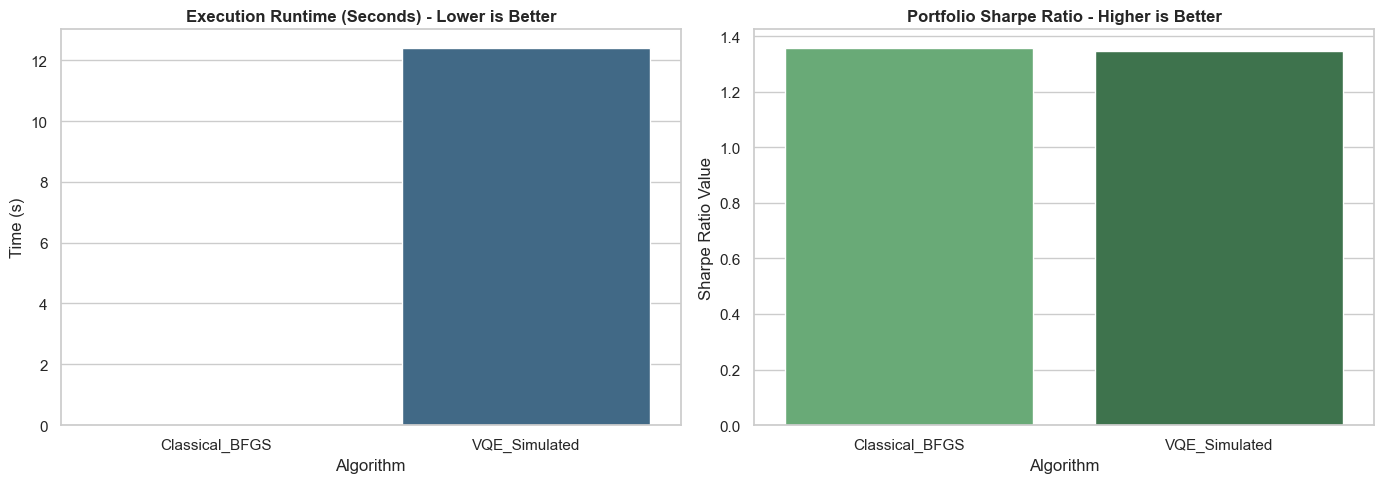

📁 Performance report visualization exported cleanly to: quantum_vs_classical_metrics.png


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic styling
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Execution Runtime Comparison
sns.barplot(x="Algorithm", y="Runtime (s)", data=unified_table, ax=axes[0], palette="Blues_d")
axes[0].set_title("Execution Runtime (Seconds) - Lower is Better", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Time (s)")

# Plot 2: Sharpe Ratio Comparison
sns.barplot(x="Algorithm", y="Sharpe Ratio", data=unified_table, ax=axes[1], palette="Greens_d")
axes[1].set_title("Portfolio Sharpe Ratio - Higher is Better", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Sharpe Ratio Value")

plt.tight_layout()
plt.savefig("quantum_vs_classical_metrics.png", dpi=300)
plt.show()
print("📁 Performance report visualization exported cleanly to: quantum_vs_classical_metrics.png")
